# Sensitivity Analysis of Sequentially Trained Models

We perform sensitivity analysis to understand how each input feature contributes to the model's anomaly detection, identifying which features are most influential.

**Methods:**
- **Integrated Gradients (IG)**: Applied to the PNN model (`maximize_sigma`) and the PRAE model (`maximize_rec_error`). Provides per-feature attribution scores for individual samples.
- **Grouped Occlusion**: Applied to the Transformer+OC-SVM model. Occludes groups of features (by `type` and `side`) and measures the change in anomaly score.

In [1]:
import os, sys, math, logging, glob, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import joblib

sys.path.insert(0, os.path.abspath(".."))

from detection.data.datasets import get_lob
from detection.data.loaders import create_sequences
from detection.data.preprocessing import clean_lob, filter_market_hours
from detection.features.dynamics import compute_dynamics, compute_elasticity
from detection.features.event_flow import compute_event_flow
from detection.features.hawkes import compute_hawkes
from detection.features.imbalance import compute_imbalance, compute_weighted_imbalance
from detection.features.ofi import compute_ofi
from detection.features.volatility import compute_volatility
from detection.models.hybrid import TransformerOCSVM
from detection.models.pnn import PNN
from detection.models.prae import PRAE
from detection.models.transformer import BottleneckTransformer
from detection.sensitivity.integrated_gradients import IntegratedGradients, maximize_sigma, maximize_rec_error
from detection.sensitivity.occlusion import GroupedOcclusion

from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
logger = logging.getLogger(__name__)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


## Configuration & Data Preparation

In [2]:
DATA_DIR = os.path.join("..", "data", "TOTF.PA-book")
RESULTS_DIR = os.path.join("..", "results")
SEQ_LENGTH = 25
BATCH_SIZE = 64
WARMUP_STEPS = 3000
WINDOW = 50
N_IG_STEPS = 50  # Integrated Gradients interpolation steps
N_SAMPLES = 10   # Number of top-anomaly samples to explain

TAO_CONFIGS = [
    {"name": "Weighted_Imbalance_decreasing",  "weights": [0.1, 0.1, 0.2, 0.2, 0.4], "levels": 5},
    {"name": "Weighted_Imbalance_increasing",  "weights": [0.4, 0.2, 0.2, 0.1, 0.1], "levels": 5},
    {"name": "Weighted_Imbalance_constant",    "weights": [0.2, 0.2, 0.2, 0.2, 0.2], "levels": 5},
]

FILES = sorted(glob.glob(os.path.join(DATA_DIR, "*.csv.gz")))
TEST_FILE = FILES[-1]

# --- Prepare test data ---
def load_and_clean(filepath):
    df = get_lob(filepath)
    df = clean_lob(df)
    df = filter_market_hours(df, time_col="xltime", market_open_hour=9.0, market_close_hour=17.5)
    return df

def engineer_features(df):
    features = pd.DataFrame(index=df.index)
    df = df.copy()
    df = compute_imbalance(df)
    features["L1_Imbalance"] = df["L1_Imbalance"]
    features["L5_Imbalance"] = df["L5_Imbalance"]
    features = compute_dynamics(df, features, window=WINDOW)
    features = compute_elasticity(df, features)
    features = compute_volatility(df, features, window=WINDOW)
    for tc in TAO_CONFIGS:
        features[tc["name"]] = compute_weighted_imbalance(df, weights=tc["weights"], levels=tc.get("levels", 5))
    features = compute_event_flow(df, features)
    features = compute_hawkes(df, features)
    features = compute_ofi(df, features)
    features.replace([np.inf, -np.inf], np.nan, inplace=True)
    features = features.fillna(0)
    if len(features) > WARMUP_STEPS:
        features = features.iloc[WARMUP_STEPS:].reset_index(drop=True)
    lower, upper = features.quantile(0.001), features.quantile(0.999)
    features = features.clip(lower=lower, upper=upper, axis=1)
    drop_cols = features.columns[features.std() < 1e-9].tolist()
    if drop_cols:
        features = features.drop(columns=drop_cols)
    return features

df_test = load_and_clean(TEST_FILE)
df_test = df_test.iloc[:10000] #### TEST
features_test = engineer_features(df_test)
print(f"Test day: {os.path.basename(TEST_FILE)}")
print(f"Rows after warmup: {len(features_test)}, Features: {len(features_test.columns)}")

2026-02-25 13:41:57,361 | INFO | Dropped artifact columns: ['Unnamed: 1']
2026-02-25 13:41:58,268 | INFO | Market-hours filter [9.0:00 -- 17.5:00]: kept 1361713 / 1552953 rows (dropped 191240 pre/post-market).


Test day: 2015-02-05-TOTF.PA-book.csv.gz
Rows after warmup: 7000, Features: 78


## Load Models & Prepare Sequences

In [3]:
models = {}   # model_type -> (model, ocsvm_or_None)
scalers = {}
feat_names_map = {}

for model_type in ["transformer_ocsvm", "pnn", "prae"]:
    # Feature names
    feat_path = os.path.join(RESULTS_DIR, f"{model_type}_features.txt")
    if os.path.exists(feat_path):
        with open(feat_path) as f:
            feat_names = [l.strip() for l in f if l.strip()]
    else:
        feat_names = features_test.columns.tolist()
    feat_names_map[model_type] = feat_names

    # Scaler
    scaler_path = os.path.join(RESULTS_DIR, f"{model_type}_scaler.pkl")
    scalers[model_type] = joblib.load(scaler_path) if os.path.exists(scaler_path) else MinMaxScaler()

    # Model
    num_features = len(feat_names)
    weights_path = os.path.join(RESULTS_DIR, f"{model_type}_weights.pth")

    if model_type == "transformer_ocsvm":
        transformer = BottleneckTransformer(
            num_features=num_features, model_dim=64, num_heads=4,
            num_layers=2, representation_dim=128, sequence_length=SEQ_LENGTH)
        transformer.load_state_dict(torch.load(weights_path, map_location=DEVICE, weights_only=True))
        transformer.eval().to(DEVICE)
        # Nyström OC-SVM saved as PyTorch module
        ocsvm_path = weights_path.replace("_weights.pth", "_detector.pth")
        ocsvm = torch.load(ocsvm_path, map_location=DEVICE, weights_only=False) if os.path.exists(ocsvm_path) else None
        models[model_type] = (transformer, ocsvm)

    elif model_type == "pnn":
        input_dim = SEQ_LENGTH * num_features
        model = PNN(input_dim=input_dim, hidden_dim=64).to(DEVICE)
        model.load_state_dict(torch.load(weights_path, map_location=DEVICE, weights_only=True))
        model.eval()
        models[model_type] = (model, None)

    elif model_type == "prae":
        backbone = BottleneckTransformer(
            num_features=num_features, model_dim=64, num_heads=4,
            num_layers=2, representation_dim=128, sequence_length=SEQ_LENGTH)
        model = PRAE(backbone_model=backbone, num_train_samples=1, lambda_reg=1.0, sigma=0.5).to(DEVICE)
        state_dict = torch.load(weights_path, map_location=DEVICE, weights_only=True)
        state_dict = {k: v for k, v in state_dict.items() if k != "mu"}
        model.load_state_dict(state_dict, strict=False)
        model.eval()
        models[model_type] = (model, None)

    print(f"Loaded {model_type}")


def prepare_sequences(model_type):
    """Scale + sequence the test data for a given model type."""
    feat_names = feat_names_map[model_type]
    feat_df = features_test.copy()
    for col in feat_names:
        if col not in feat_df.columns:
            feat_df[col] = 0.0
    feat_df = feat_df[feat_names]
    scaler = scalers[model_type]
    scaled = scaler.transform(feat_df.values.astype(np.float32)).astype(np.float32)
    sequences = create_sequences(scaled, SEQ_LENGTH)
    return torch.tensor(sequences, dtype=torch.float32), scaled, feat_names

print("All models loaded.")

Loaded transformer_ocsvm
Loaded pnn
Loaded prae
All models loaded.


## Identify Top Anomaly Samples

We compute anomaly scores for each model and select the top-N samples to explain.

In [4]:
top_indices = {}  # model_type -> array of top anomaly indices into sequences

for model_type in ["pnn", "prae", "transformer_ocsvm"]:
    x_seq, scaled, feat_names = prepare_sequences(model_type)
    model, ocsvm = models[model_type]

    if model_type == "pnn":
        # NLL scores
        target_idx = feat_names.index("log_return") if "log_return" in feat_names else 0
        targets = scaled[SEQ_LENGTH:, target_idx]
        x_flat = x_seq.reshape(x_seq.size(0), -1).to(DEVICE)
        y = torch.tensor(targets[:len(x_flat)], dtype=torch.float32).unsqueeze(1).to(DEVICE)
        with torch.no_grad():
            mu, sigma, alpha = model(x_flat)
            z = (y - mu) / sigma
            phi_z = (1.0 / math.sqrt(2 * math.pi)) * torch.exp(-0.5 * z**2)
            big_phi = 0.5 * (1 + torch.erf(alpha * z / math.sqrt(2)))
            pdf = (2.0 / sigma) * phi_z * big_phi
            nll = -torch.log(pdf + 1e-10)
            scores = nll.cpu().numpy().flatten()

    elif model_type == "prae":
        loader = DataLoader(TensorDataset(x_seq, x_seq), batch_size=BATCH_SIZE, shuffle=False)
        sc_list = []
        with torch.no_grad():
            for b in loader:
                x = b[0].to(DEVICE)
                rec, _ = model(x, training=False)
                sc_list.append(torch.sum((x - rec)**2, dim=tuple(range(1, x.dim()))).cpu().numpy())
        scores = np.concatenate(sc_list)

    elif model_type == "transformer_ocsvm":
        loader = DataLoader(TensorDataset(x_seq, x_seq), batch_size=BATCH_SIZE, shuffle=False)
        if ocsvm is not None:
            det = TransformerOCSVM.__new__(TransformerOCSVM)
            det.transformer = model
            det.ocsvm = ocsvm
            scores = det.predict(loader)
        else:
            sc_list = []
            with torch.no_grad():
                for b in loader:
                    x = b[0].to(DEVICE)
                    rec = model(x)
                    sc_list.append(torch.mean((x - rec)**2, dim=(1,2)).cpu().numpy())
            scores = np.concatenate(sc_list)

    # Top N anomalies
    top_idx = np.argsort(scores)[-N_SAMPLES:][::-1]
    top_indices[model_type] = top_idx
    print(f"{model_type}: top {N_SAMPLES} anomaly indices = {top_idx.tolist()}")
    print(f"  scores: {scores[top_idx].tolist()}")

pnn: top 10 anomaly indices = [2126, 5978, 6864, 2016, 2001, 6297, 2121, 2123, 3343, 6247]
  scores: [17.587060928344727, 16.623586654663086, 16.599281311035156, 16.245683670043945, 16.198474884033203, 16.178773880004883, 16.051719665527344, 15.889484405517578, 15.881399154663086, 15.845612525939941]
prae: top 10 anomaly indices = [2121, 2123, 2120, 2122, 2125, 2124, 2126, 2128, 2119, 2129]
  scores: [6809.66552734375, 6801.966796875, 6784.13671875, 6784.1162109375, 6781.05712890625, 6769.3837890625, 6761.79541015625, 6747.95068359375, 6732.74951171875, 6732.462890625]
transformer_ocsvm: top 10 anomaly indices = [3171, 3310, 3311, 3313, 3307, 3312, 3177, 3176, 3306, 3314]
  scores: [-0.021559476852416992, -0.021566294133663177, -0.02159138023853302, -0.021715298295021057, -0.02190699428319931, -0.022054247558116913, -0.022173017263412476, -0.02225053310394287, -0.022265300154685974, -0.022520773112773895]


## Integrated Gradients -- PNN (`maximize_sigma`)

For the PNN model, we use IG with `maximize_sigma` as the target function. The PNN forward pass expects flattened inputs; IG expects (1, Seq, Feat). We reshape internally.

PNN -- Top 15 features by mean |IG attribution| (maximize_sigma):


,Feature,Mean |Attribution|
33,SMA_size_bid,4.098842
34,SMA_size_ask,3.629156
6,ask_depth_ratio,0.971740
5,bid_depth_ratio,0.487011
81,Hawkes_M_bid_beta1000,0.477395
32,size_trade_ask,0.458999
21,abs_velocity,0.451332
16,ask_slope,0.443628
2,mid_price,0.441105
23,log_dt,0.408389


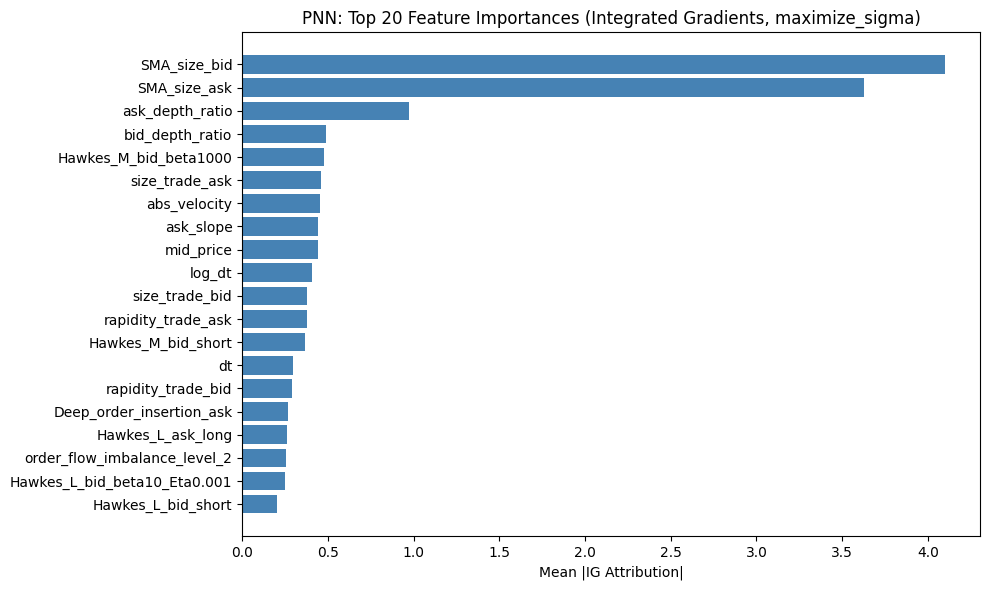

In [5]:
x_seq_pnn, _, feat_names_pnn = prepare_sequences("pnn")
pnn_model = models["pnn"][0]

# Wrap PNN to accept (Batch, Seq, Feat) and reshape internally
class PNNSeqWrapper(torch.nn.Module):
    def __init__(self, pnn):
        super().__init__()
        self.pnn = pnn
    def forward(self, x):
        flat = x.reshape(x.size(0), -1)
        return self.pnn(flat)

pnn_wrapper = PNNSeqWrapper(pnn_model).to(DEVICE)
ig_pnn = IntegratedGradients(pnn_wrapper)

# Compute attributions for top anomalies
pnn_attributions = []
for idx in top_indices["pnn"]:
    sample = x_seq_pnn[idx].unsqueeze(0).to(DEVICE)  # (1, Seq, Feat)
    attrs = ig_pnn.attribute(sample, target_func=maximize_sigma, n_steps=N_IG_STEPS)
    pnn_attributions.append(attrs.detach().cpu().numpy().squeeze())

# Aggregate: mean absolute attribution per feature (averaged over time steps and samples)
pnn_attr_array = np.array(pnn_attributions)  # (N_SAMPLES, Seq, Feat)
mean_attr_per_feature = np.mean(np.abs(pnn_attr_array), axis=(0, 1))  # (Feat,)

pnn_importance = pd.DataFrame({
    "Feature": feat_names_pnn,
    "Mean |Attribution|": mean_attr_per_feature
}).sort_values("Mean |Attribution|", ascending=False)

print("PNN -- Top 15 features by mean |IG attribution| (maximize_sigma):")
display(pnn_importance.head(15))

# Bar chart
fig, ax = plt.subplots(figsize=(10, 6))
top20 = pnn_importance.head(20)
ax.barh(top20["Feature"][::-1], top20["Mean |Attribution|"][::-1], color="steelblue")
ax.set_xlabel("Mean |IG Attribution|")
ax.set_title("PNN: Top 20 Feature Importances (Integrated Gradients, maximize_sigma)")
plt.tight_layout()
plt.show()

## Integrated Gradients -- PRAE (`maximize_rec_error`)

For the PRAE model, the target function measures reconstruction error, highlighting which features are hardest to reconstruct for anomalous samples.

PRAE -- Top 15 features by mean |IG attribution| (maximize_rec_error):


,Feature,Mean |Attribution|
33,SMA_size_bid,97.568901
34,SMA_size_ask,71.480881
53,Hawkes_L_bid_beta10_Eta0.001,47.504772
61,Hawkes_L_bid_beta100_Eta0.001,12.894343
47,Hawkes_M_bid_short,6.384004
74,Hawkes_L_ask_beta1000_Eta1.0,5.947527
81,Hawkes_M_bid_beta1000,5.610319
32,size_trade_ask,5.568682
6,ask_depth_ratio,5.353491
72,Hawkes_L_ask_beta1000_Eta0.1,4.885748


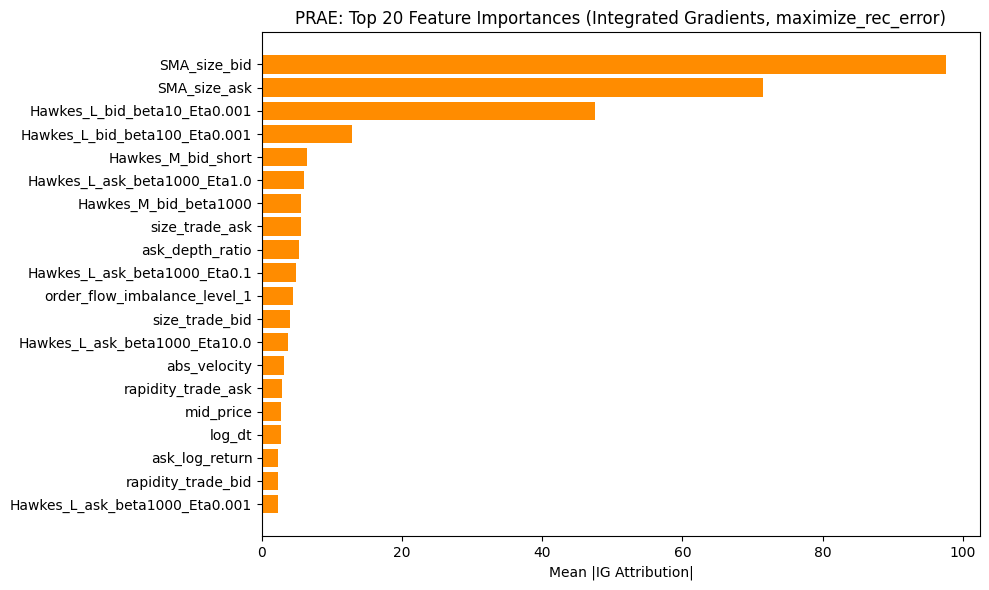

In [6]:
x_seq_prae, _, feat_names_prae = prepare_sequences("prae")
prae_model = models["prae"][0]

# PRAE forward returns (reconstructed, z). IG target_func receives (output, inputs).
# maximize_rec_error already handles this: rec = output[0], then sum((inputs - rec)**2)
ig_prae = IntegratedGradients(prae_model)

prae_attributions = []
for idx in top_indices["prae"]:
    sample = x_seq_prae[idx].unsqueeze(0).to(DEVICE)  # (1, Seq, Feat)
    attrs = ig_prae.attribute(sample, target_func=maximize_rec_error, n_steps=N_IG_STEPS)
    prae_attributions.append(attrs.detach().cpu().numpy().squeeze())

prae_attr_array = np.array(prae_attributions)  # (N_SAMPLES, Seq, Feat)
mean_attr_prae = np.mean(np.abs(prae_attr_array), axis=(0, 1))  # (Feat,)

prae_importance = pd.DataFrame({
    "Feature": feat_names_prae,
    "Mean |Attribution|": mean_attr_prae
}).sort_values("Mean |Attribution|", ascending=False)

print("PRAE -- Top 15 features by mean |IG attribution| (maximize_rec_error):")
display(prae_importance.head(15))

fig, ax = plt.subplots(figsize=(10, 6))
top20 = prae_importance.head(20)
ax.barh(top20["Feature"][::-1], top20["Mean |Attribution|"][::-1], color="darkorange")
ax.set_xlabel("Mean |IG Attribution|")
ax.set_title("PRAE: Top 20 Feature Importances (Integrated Gradients, maximize_rec_error)")
plt.tight_layout()
plt.show()

## Grouped Occlusion -- Transformer + OC-SVM

We use `GroupedOcclusion` to measure the impact of occluding feature groups on the OC-SVM anomaly score. We run two groupings: by **feature type** and by **side** (bid / ask / neutral).


Transformer+OC-SVM Grouped Occlusion (group_by='type'):


,Group,Importance,Importance_Per_Feature,Num_Features
0,time,3.491715e-04,1.745857e-04,2
1,slope,9.773895e-05,4.886948e-05,2
2,mid_price,1.481175e-05,2.962351e-06,5
3,cancel,1.257956e-05,2.096593e-06,6
4,sweep,1.492351e-06,1.492351e-06,1
5,speed,2.980232e-09,1.490116e-09,2
6,sma,2.235174e-09,1.117587e-09,2
7,spread,0.000000e+00,0.000000e+00,1
8,dynamics,0.000000e+00,0.000000e+00,1
9,return,0.000000e+00,0.000000e+00,3


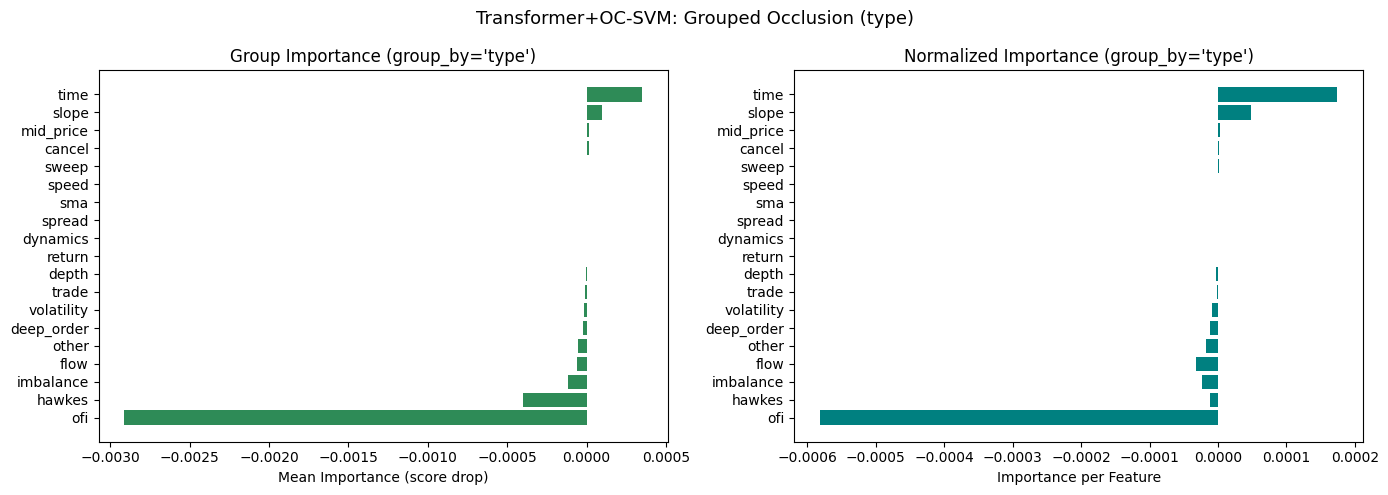


Transformer+OC-SVM Grouped Occlusion (group_by='side'):


,Group,Importance,Importance_Per_Feature,Num_Features
0,bid,-0.000028,-8.383484e-07,33
1,ask,-0.000429,-1.339146e-05,32
2,neutral,-0.002955,-1.284835e-04,23


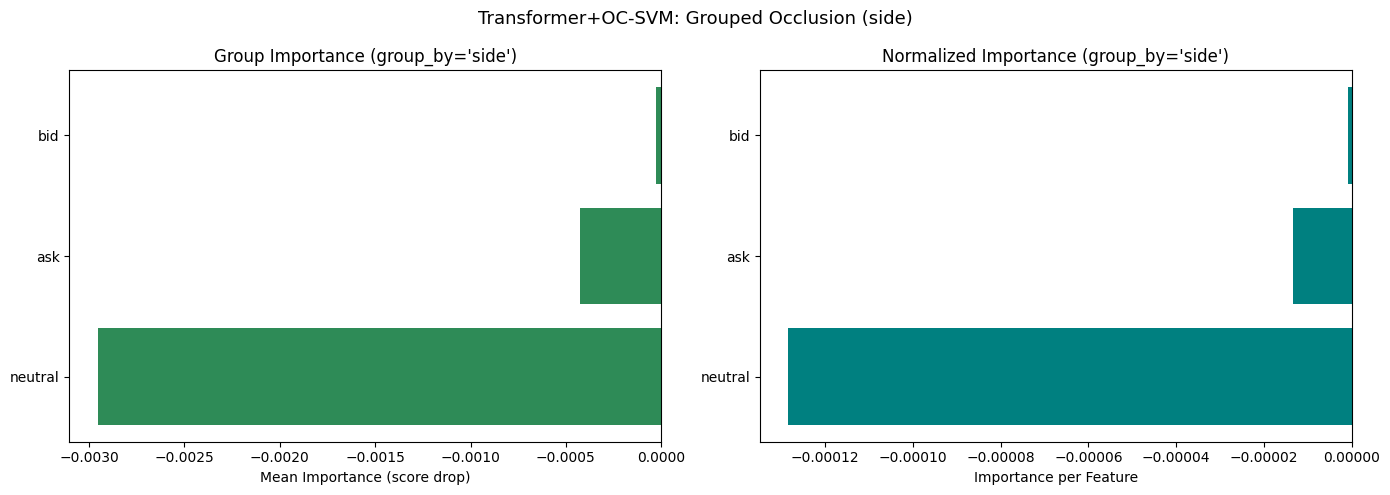

In [7]:
x_seq_tocsvm, _, feat_names_tocsvm = prepare_sequences("transformer_ocsvm")
transformer, ocsvm = models["transformer_ocsvm"]

if ocsvm is None:
    print("WARNING: OC-SVM not found; Grouped Occlusion requires the full TransformerOCSVM detector. Skipping.")
else:
    # Build a detector object for GroupedOcclusion
    detector = TransformerOCSVM.__new__(TransformerOCSVM)
    detector.transformer = transformer
    detector.ocsvm = ocsvm

    # Run grouped occlusion for each top anomaly, with two groupings
    for group_by in ["type", "side"]:
        all_importance_dfs = []
        all_feature_lists = {}

        for idx in top_indices["transformer_ocsvm"]:
            sample = x_seq_tocsvm[idx].unsqueeze(0).to(DEVICE)
            imp_df, feat_lists = GroupedOcclusion(
                detector, sample, feat_names_tocsvm,
                group_by=group_by, baseline_mode="mean")
            all_importance_dfs.append(imp_df)
            all_feature_lists.update(feat_lists)

        # Average importance across samples
        avg_imp = pd.concat(all_importance_dfs).groupby("Group").agg({
            "Importance": "mean",
            "Importance_Per_Feature": "mean",
            "Num_Features": "first",
        }).sort_values("Importance", ascending=False).reset_index()

        print(f"\nTransformer+OC-SVM Grouped Occlusion (group_by='{group_by}'):")
        display(avg_imp)

        # Plot
        fig, axes_occ = plt.subplots(1, 2, figsize=(14, 5))

        ax1 = axes_occ[0]
        ax1.barh(avg_imp["Group"][::-1], avg_imp["Importance"][::-1], color="seagreen")
        ax1.set_xlabel("Mean Importance (score drop)")
        ax1.set_title(f"Group Importance (group_by='{group_by}')")

        ax2 = axes_occ[1]
        ax2.barh(avg_imp["Group"][::-1], avg_imp["Importance_Per_Feature"][::-1], color="teal")
        ax2.set_xlabel("Importance per Feature")
        ax2.set_title(f"Normalized Importance (group_by='{group_by}')")

        plt.suptitle(f"Transformer+OC-SVM: Grouped Occlusion ({group_by})", fontsize=13)
        plt.tight_layout()
        plt.show()

## Cross-Model Feature Importance Comparison

Top 15 features by average normalized importance (PNN + PRAE):


,Feature,PNN_attr,PRAE_attr,PNN_attr_norm,PRAE_attr_norm,avg_norm
43,SMA_size_bid,4.098842,97.568901,1.000000,1.000000,1.000000
42,SMA_size_ask,3.629156,71.480881,0.885410,0.732620,0.809015
24,Hawkes_L_bid_beta10_Eta0.001,0.248614,47.504772,0.060655,0.486884,0.273770
50,ask_depth_ratio,0.971740,5.353491,0.237077,0.054869,0.145973
36,Hawkes_M_bid_beta1000,0.477395,5.610319,0.116471,0.057501,0.086986
83,size_trade_ask,0.458999,5.568682,0.111983,0.057074,0.084528
37,Hawkes_M_bid_short,0.367621,6.384004,0.089689,0.065431,0.077560
20,Hawkes_L_bid_beta100_Eta0.001,0.061289,12.894343,0.014953,0.132156,0.073554
49,abs_velocity,0.451332,3.125943,0.110112,0.032038,0.071075
65,mid_price,0.441105,2.699809,0.107617,0.027671,0.067644


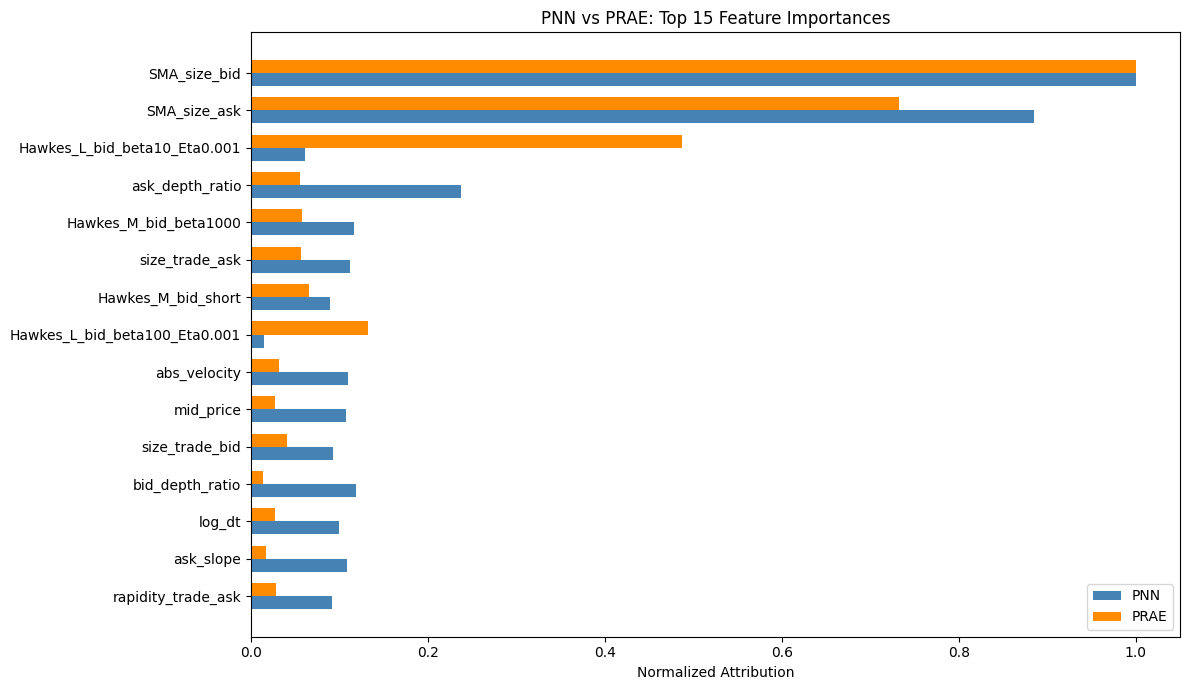

In [8]:
# Compare PNN and PRAE top features side by side
merged = pnn_importance.rename(columns={"Mean |Attribution|": "PNN_attr"}).merge(
    prae_importance.rename(columns={"Mean |Attribution|": "PRAE_attr"}),
    on="Feature", how="outer"
).fillna(0)

# Normalize to [0, 1] for comparison
for col in ["PNN_attr", "PRAE_attr"]:
    mx = merged[col].max()
    if mx > 0:
        merged[col + "_norm"] = merged[col] / mx
    else:
        merged[col + "_norm"] = 0

# Average rank
merged["avg_norm"] = (merged["PNN_attr_norm"] + merged["PRAE_attr_norm"]) / 2
merged = merged.sort_values("avg_norm", ascending=False)

print("Top 15 features by average normalized importance (PNN + PRAE):")
display(merged[["Feature", "PNN_attr", "PRAE_attr", "PNN_attr_norm", "PRAE_attr_norm", "avg_norm"]].head(15))

# Side-by-side plot
fig, ax = plt.subplots(figsize=(12, 7))
top15 = merged.head(15)
y_pos = np.arange(len(top15))
width = 0.35
ax.barh(y_pos - width/2, top15["PNN_attr_norm"].values[::-1], width, label="PNN", color="steelblue")
ax.barh(y_pos + width/2, top15["PRAE_attr_norm"].values[::-1], width, label="PRAE", color="darkorange")
ax.set_yticks(y_pos)
ax.set_yticklabels(top15["Feature"].values[::-1])
ax.set_xlabel("Normalized Attribution")
ax.set_title("PNN vs PRAE: Top 15 Feature Importances")
ax.legend()
plt.tight_layout()
plt.show()